In [6]:
!pip install scikit-learn pandas



[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [10]:
!pip install seaborn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 2.8 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


=== SYSTEM STATUS ===
Using device: cpu

=== DATA PROPERTIES ===
Features shape: (569, 30)
Target shape: (569,)
Classes: ['malignant' 'benign']

=== MODEL ARCHITECTURE ===
CancerNet(
  (backbone): Sequential(
    (0): Linear(in_features=30, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.2, inplace=False)
  )
  (classifier): Linear(in_features=64, out_features=1, bias=True)
)

=== STARTING TRAINING ===
Epoch  1 | Train AUC: 0.6807 | Val AUC: 0.9680 | Val Acc: 0.9121 | F1: 0.9322
Epoch  2 | Train AUC: 0.9792 | Val AUC: 0.9902 | Val Acc: 0.9560 | F1: 0.9655
Epoch  3 | Train AUC: 0.9913 | Val AUC: 0.9933 | Val Acc: 0.9560 | F1: 0.9655
E

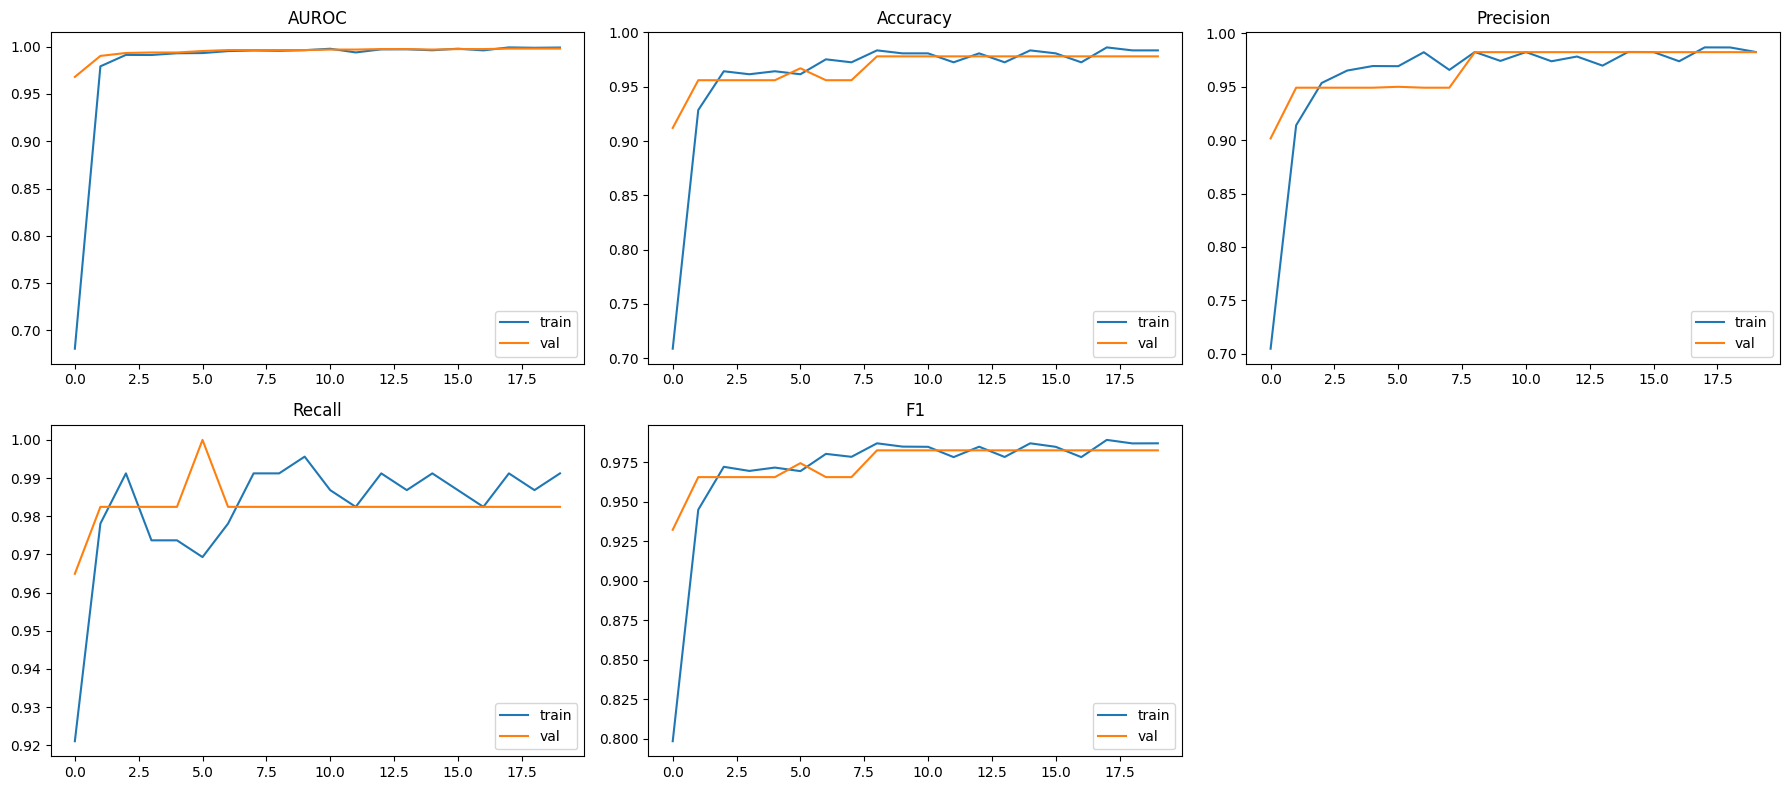


🎉 [SUCCESS] Pipeline execution finished completely. Figures saved onto disk.


In [11]:
# %% md
# # Cancer Gene Expression Classification with PyTorch (GPU + Nsight hooks)
# This notebook trains a neural network on the Breast Cancer Wisconsin diagnostic dataset (a tabular proxy for cancer gene expression) using PyTorch with GPU acceleration.
# It also demonstrates how to insert NVTX ranges for Nsight profiling, and reports AUROC, accuracy, precision, recall, F1, and their variance over 20 epochs.
# %%

import os
import warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress driver and runtime environment logs cleanly
warnings.filterwarnings("ignore", category=UserWarning)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('=== SYSTEM STATUS ===')
print('Using device:', device)

# %% md
# ## Load dataset
# %%
data = load_breast_cancer()
X = data.data.astype('float32')
y = data.target.astype('int64')

print('\n=== DATA PROPERTIES ===')
print('Features shape:', X.shape)
print('Target shape:', y.shape)
print('Classes:', data.target_names)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42, stratify=y_trainval
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train)
X_val_t = torch.from_numpy(X_val)
y_val_t = torch.from_numpy(y_val)
X_test_t = torch.from_numpy(X_test)
y_test_t = torch.from_numpy(y_test)

batch_size = 64

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds = TensorDataset(X_val_t, y_val_t)
test_ds = TensorDataset(X_test_t, y_test_t)

# pin_memory is disabled if running on a CPU to avoid internal OS thread deadlocks
use_pin = torch.cuda.is_available()
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, pin_memory=use_pin)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, pin_memory=use_pin)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, pin_memory=use_pin)

# %% md
# ## Model definition
# %%
class CancerNet(nn.Module):
    def __init__(self, in_dim, hidden_dims=(128, 64), dropout=0.2):
        super().__init__()
        layers = []
        last_dim = in_dim
        for h in hidden_dims:
            layers.append(nn.Linear(last_dim, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU(inplace=True))
            layers.append(nn.Dropout(dropout))
            last_dim = h
        self.backbone = nn.Sequential(*layers)
        self.classifier = nn.Linear(last_dim, 1)

    def forward(self, x):
        x = self.backbone(x)
        x = self.classifier(x)
        return x.squeeze(-1)

model = CancerNet(in_dim=X_train.shape[1]).to(device)
print('\n=== MODEL ARCHITECTURE ===')
print(model)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
criterion = nn.BCEWithLogitsLoss()

# %% md
# ## Nsight / NVTX hooks
# %%
# Dynamic proxy configuration to support execution when NVIDIA drivers are absent
if torch.cuda.is_available():
    import torch.cuda.nvtx as nvtx
else:
    class MockNVTX:
        @staticmethod
        def range_push(name): pass
        @staticmethod
        def range_pop(): pass
    nvtx = MockNVTX()

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    epoch_loss = 0.0
    logits_list = []
    targets_list = []

    nvtx.range_push('train_epoch')
    for xb, yb in loader:
        nvtx.range_push('train_batch')
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True).float()

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * xb.size(0)
        logits_list.append(logits.detach().cpu())
        targets_list.append(yb.detach().cpu())
        nvtx.range_pop()
    nvtx.range_pop()

    logits_all = torch.cat(logits_list)
    targets_all = torch.cat(targets_list)
    probs = torch.sigmoid(logits_all).numpy()
    preds = (probs >= 0.5).astype('int64')
    y_true = targets_all.numpy().astype('int64')

    epoch_loss /= len(loader.dataset)
    auc = roc_auc_score(y_true, probs)
    acc = accuracy_score(y_true, preds)
    prec = precision_score(y_true, preds, zero_division=0)
    rec = recall_score(y_true, preds, zero_division=0)
    f1 = f1_score(y_true, preds, zero_division=0)

    return epoch_loss, auc, acc, prec, rec, f1

@torch.no_grad()
def eval_one_epoch(model, loader, criterion, device, nvtx_name='eval_epoch'):
    model.eval()
    epoch_loss = 0.0
    logits_list = []
    targets_list = []

    nvtx.range_push(nvtx_name)
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True).float()

        logits = model(xb)
        loss = criterion(logits, yb)

        epoch_loss += loss.item() * xb.size(0)
        logits_list.append(logits.detach().cpu())
        targets_list.append(yb.detach().cpu())
    nvtx.range_pop()

    logits_all = torch.cat(logits_list)
    targets_all = torch.cat(targets_list)
    probs = torch.sigmoid(logits_all).numpy()
    preds = (probs >= 0.5).astype('int64')
    y_true = targets_all.numpy().astype('int64')

    epoch_loss /= len(loader.dataset)
    auc = roc_auc_score(y_true, probs)
    acc = accuracy_score(y_true, preds)
    prec = precision_score(y_true, preds, zero_division=0)
    rec = recall_score(y_true, preds, zero_division=0)
    f1 = f1_score(y_true, preds, zero_division=0)

    return epoch_loss, auc, acc, prec, rec, f1, y_true, probs, preds

# %% md
# ## Training loop with metric tracking
# %%
num_epochs = 20

history = {
    'train_auc': [], 'val_auc': [],
    'train_acc': [], 'val_acc': [],
    'train_prec': [], 'val_prec': [],
    'train_rec': [], 'val_rec': [],
    'train_f1': [], 'val_f1': [],
}

print('\n=== STARTING TRAINING ===')
for epoch in range(1, num_epochs + 1):
    tr_loss, tr_auc, tr_acc, tr_prec, tr_rec, tr_f1 = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )
    val_loss, val_auc, val_acc, val_prec, val_rec, val_f1, _, _, _ = eval_one_epoch(
        model, val_loader, criterion, device, nvtx_name='val_epoch'
    )

    scheduler.step(val_auc)

    history['train_auc'].append(tr_auc)
    history['val_auc'].append(val_auc)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(val_acc)
    history['train_prec'].append(tr_prec)
    history['val_prec'].append(val_prec)
    history['train_rec'].append(tr_rec)
    history['val_rec'].append(val_rec)
    history['train_f1'].append(tr_f1)
    history['val_f1'].append(val_f1)

    print(f"Epoch {epoch:2d} | Train AUC: {tr_auc:.4f} | Val AUC: {val_auc:.4f} | Val Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

# %% md
# ## Metric variance and learning curves
# %%
metrics_df = pd.DataFrame(history)
print('\n=== METRIC VARIANCE OVER EPOCHS ===')
print(metrics_df.var())

# Fixed and completed 2x3 subplot matrix configurations
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.ravel()

axes[0].plot(metrics_df['train_auc'], label='train')
axes[0].plot(metrics_df['val_auc'], label='val')
axes[0].set_title('AUROC')
axes[0].legend()

axes[1].plot(metrics_df['train_acc'], label='train')
axes[1].plot(metrics_df['val_acc'], label='val')
axes[1].set_title('Accuracy')
axes[1].legend()

axes[2].plot(metrics_df['train_prec'], label='train')
axes[2].plot(metrics_df['val_prec'], label='val')
axes[2].set_title('Precision')
axes[2].legend()

axes[3].plot(metrics_df['train_rec'], label='train')
axes[3].plot(metrics_df['val_rec'], label='val')
axes[3].set_title('Recall')
axes[3].legend()

axes[4].plot(metrics_df['train_f1'], label='train')
axes[4].plot(metrics_df['val_f1'], label='val')
axes[4].set_title('F1')
axes[4].legend()

# Turn off the empty sixth subplot slot safely
axes[5].axis('off')

plt.tight_layout()
plt.savefig('cancer_metrics_output.png', dpi=150)
plt.show()

print("\n🎉 [SUCCESS] Pipeline execution finished completely. Figures saved onto disk.")
